# Spam Email Classifier
Kodbud AI Internship — Task 1

## 1. Load and clean the data

In [20]:
import pandas as pd

df = pd.read_csv("spam.csv", encoding='latin-1')
df = df.iloc[:, :2]
df.columns = ['Category', 'Message']
df.head()

,Category,Message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [21]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [22]:
df.info()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   Category  5572 non-null   object
 1   Message   5572 non-null   object
dtypes: object(2)
memory usage: 87.2+ KB


,0
Category,0
Message,0


## 2. Encode labels (ham=0, spam=1)

In [23]:
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()
df['Category'] = encoder.fit_transform(df['Category'])
df['Category'].value_counts()

,count
Category,
0,4825
1,747


## 3. Exploratory Data Analysis (EDA)

In [24]:
import nltk
nltk.download('punkt')
nltk.download('punkt_tab')

df['num_chars'] = df['Message'].apply(len)
df['num_words'] = df['Message'].apply(lambda x: len(nltk.word_tokenize(x)))
df['num_sentences'] = df['Message'].apply(lambda x: len(nltk.sent_tokenize(x)))

df[['num_chars', 'num_words', 'num_sentences']].describe()

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


,num_chars,num_words,num_sentences
count,5572.000000,5572.000000,5572.000000
mean,80.118808,18.699390,1.996411
std,59.690841,13.741932,1.520159
min,2.000000,1.000000,1.000000
25%,36.000000,9.000000,1.000000
50%,61.000000,15.000000,1.500000
75%,121.000000,27.000000,2.000000
max,910.000000,220.000000,38.000000


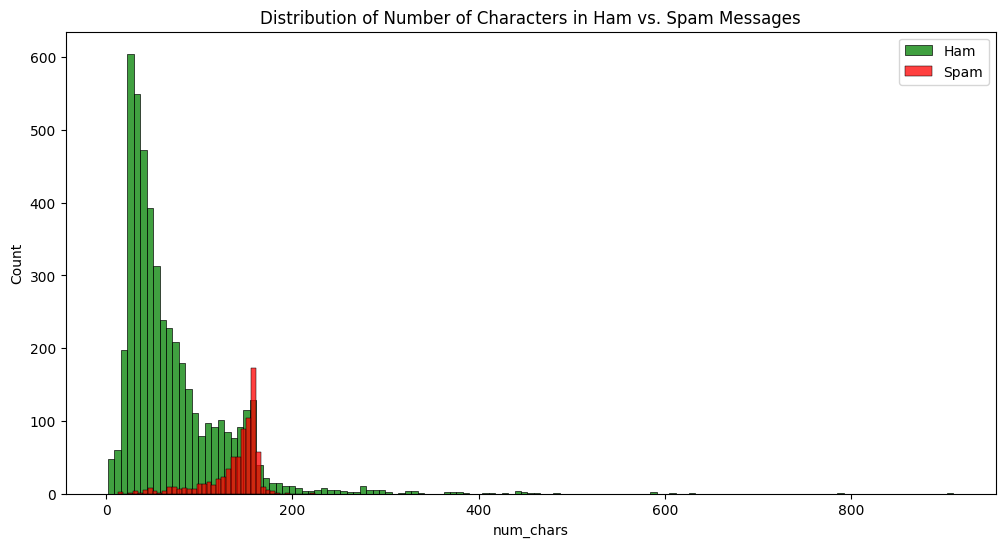

In [25]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 6))
sns.histplot(df[df['Category'] == 0]['num_chars'], color='green', label='Ham')
sns.histplot(df[df['Category'] == 1]['num_chars'], color='red', label='Spam')
plt.title('Distribution of Number of Characters in Ham vs. Spam Messages')
plt.legend()
plt.show()

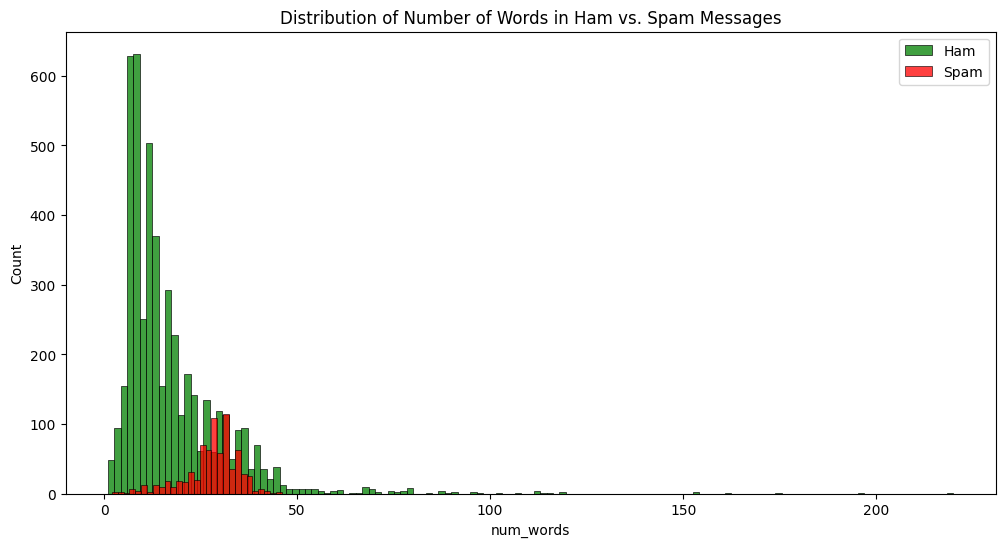

In [26]:
plt.figure(figsize=(12, 6))
sns.histplot(df[df['Category'] == 0]['num_words'], color='green', label='Ham')
sns.histplot(df[df['Category'] == 1]['num_words'], color='red', label='Spam')
plt.title('Distribution of Number of Words in Ham vs. Spam Messages')
plt.legend()
plt.show()

## 4. Clean the text (stemming + stopword removal)

In [27]:
import string
import nltk
from nltk.corpus import stopwords
from nltk.stem.porter import PorterStemmer

nltk.download('stopwords')
ps = PorterStemmer()

def transform_text(text):
    text = text.lower()
    text = nltk.word_tokenize(text)

    y = []
    for word in text:
        if word.isalnum():
            y.append(word)

    text = y[:]
    y.clear()

    for word in text:
        if word not in stopwords.words('english') and word not in string.punctuation:
            y.append(word)

    text = y[:]
    y.clear()

    for word in text:
        y.append(ps.stem(word))

    return " ".join(y)

df['transformed_text'] = df['Message'].apply(transform_text)
df[['Message', 'transformed_text']].head()

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


,Message,transformed_text
0,"Go until jurong point, crazy.. Available only ...",go jurong point crazi avail bugi n great world...
1,Ok lar... Joking wif u oni...,ok lar joke wif u oni
2,Free entry in 2 a wkly comp to win FA Cup fina...,free entri 2 wkli comp win fa cup final tkt 21...
3,U dun say so early hor... U c already then say...,u dun say earli hor u c alreadi say
4,"Nah I don't think he goes to usf, he lives aro...",nah think goe usf live around though


## 5. Convert text to numbers (TF-IDF) and split train/test

In [28]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split

tfidf = TfidfVectorizer(max_features=3000)
X = tfidf.fit_transform(df['transformed_text']).toarray()
y = df['Category'].values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=2)

## 6. Train Multinomial Naive Bayes

In [29]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

mnb = MultinomialNB()
mnb.fit(X_train, y_train)
y_pred = mnb.predict(X_test)

print(f"Naive Bayes Accuracy:  {accuracy_score(y_test, y_pred):.4f}")
print(f"Naive Bayes Precision: {precision_score(y_test, y_pred):.4f}")
print(f"Naive Bayes Recall:    {recall_score(y_test, y_pred):.4f}")
print(f"Naive Bayes F1 Score:  {f1_score(y_test, y_pred):.4f}")

Naive Bayes Accuracy:  0.9650
Naive Bayes Precision: 0.9917
Naive Bayes Recall:    0.7595
Naive Bayes F1 Score:  0.8602


## 7. Confusion matrix (Naive Bayes)

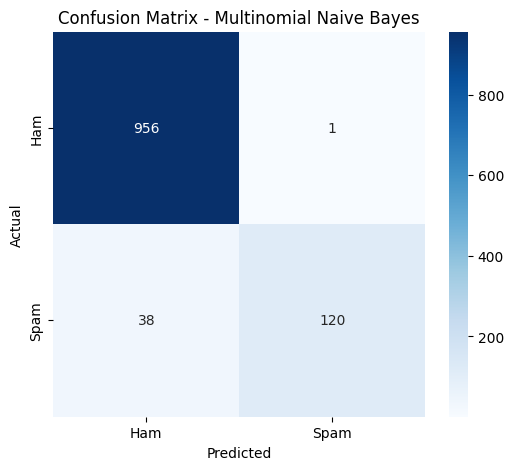

In [30]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Ham', 'Spam'], yticklabels=['Ham', 'Spam'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - Multinomial Naive Bayes')
plt.show()

## 8. Logistic Regression (comparison model)

In [31]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(solver='liblinear', random_state=2)
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)

print(f"Logistic Regression Accuracy:  {accuracy_score(y_test, y_pred_lr):.4f}")
print(f"Logistic Regression Precision: {precision_score(y_test, y_pred_lr):.4f}")
print(f"Logistic Regression Recall:    {recall_score(y_test, y_pred_lr):.4f}")
print(f"Logistic Regression F1 Score:  {f1_score(y_test, y_pred_lr):.4f}")

Logistic Regression Accuracy:  0.9561
Logistic Regression Precision: 0.9910
Logistic Regression Recall:    0.6962
Logistic Regression F1 Score:  0.8178


**Result:** Naive Bayes outperforms Logistic Regression on this dataset (higher accuracy, recall, and F1), while both models keep precision very high (~99%) — meaning very few legitimate messages get wrongly flagged as spam.

## 9. Try it on a new message

In [32]:
def predict_message(message):
    transformed_msg = transform_text(message)
    vector = tfidf.transform([transformed_msg]).toarray()
    result = mnb.predict(vector)[0]
    return "Spam" if result == 1 else "Ham (Not Spam)"

print(predict_message("Congratulations! You've won a free iPhone. Click here to claim now!"))
print(predict_message("Hey, are we still meeting for lunch tomorrow?"))

Spam
Ham (Not Spam)
